# Module 2 — Advanced Regression & Model Interpretability
Course: Advanced Predictive Analytics

This notebook contains: theory, practical code, and exercises for **Regularization, GLMs, Survival Analysis, Model Explainability, and Neural Networks**.

Run the cells sequentially. Cells that require extra packages (e.g., `lifelines`, `shap`) include optional install notes.

## Table of contents
1. Data generation & exploration (synthetic datasets)
2. Regularization: Ridge, Lasso, ElasticNet
3. GLMs: Poisson regression (count data) example
4. Survival analysis: Kaplan-Meier estimator (manual implementation)
5. Model interpretability: permutation importance + SHAP (optional)
6. Neural network: MLPRegressor for regression
7. Mini-project exercise prompts and deliverables

---
Each section contains explanation, code, and short exercises for students.

## 1. Data generation & exploration
We create synthetic datasets that mimic real business problems:
- `spend_data`: continuous target for annual spend (regression)
- `count_data`: count target for number of transactions (Poisson)
- `churn_data`: time-to-churn with censoring (survival)

These datasets are intentionally simple but include correlations, skewness, and noise.

In [2]:
# Generate synthetic datasets
import numpy as np, pandas as pd
np.random.seed(42)

n = 2000
# Features
age = np.random.randint(18, 70, n)
income = np.random.normal(50000, 20000, n).clip(10000, 200000)
engagement = np.random.poisson(3, n)  # visits per month
marketing_emails = np.random.binomial(1, 0.3, n)
web_visits = np.random.poisson(10, n) + (income/20000).astype(int)

# Create spend (skewed)
base = 200 + 0.05*income + 20*engagement - 150*marketing_emails + np.random.normal(0,1000,n)
spend = (np.exp(np.log(np.abs(base)+1)) - 1) + np.random.gamma(2,500,n)  # add skewness

spend_data = pd.DataFrame({
    'age': age, 'income': income, 'engagement': engagement,
    'marketing_emails': marketing_emails, 'web_visits': web_visits,
    'spend': spend
})

# Count data (transactions) - Poisson-like
lambda_tx = np.exp(-1 + 0.00002*income + 0.2*engagement)
transactions = np.random.poisson(lambda_tx)
count_data = pd.DataFrame({'age': age, 'income': income, 'engagement': engagement, 'transactions': transactions})

# Survival-like data (time to churn in months) with censoring
baseline_hazard = 0.02  # baseline monthly hazard
hazard = baseline_hazard * (1 + 0.5*(engagement<2) + 0.3*(income<40000))
time_to_event = np.random.exponential(1/hazard)
censor_time = np.random.uniform(6, 36, n)  # varied observation window
observed_time = np.minimum(time_to_event, censor_time)
event_observed = (time_to_event <= censor_time).astype(int)
churn_data = pd.DataFrame({'age': age, 'income': income, 'engagement': engagement,
                           'tenure_months': observed_time, 'churned': event_observed})

# Save sample to CSV for student convenience
spend_data.to_csv('spend_data_sample.csv', index=False)
count_data.to_csv('count_data_sample.csv', index=False)
churn_data.to_csv('churn_data_sample.csv', index=False)

print('Datasets created: spend_data, count_data, churn_data. CSV samples saved in notebook folder.')

Datasets created: spend_data, count_data, churn_data. CSV samples saved in notebook folder.


## 2. Regularization (Ridge, Lasso, ElasticNet)
### Concept recap:
- Ridge (L2) penalizes sum of squares of coefficients — keeps all features but shrinks them.
- Lasso (L1) penalizes sum of absolute coefficients — can set some to zero (feature selection).
- ElasticNet mixes L1 and L2.

### Code: fit and compare models (with scaling and cross-validation).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data
X = spend_data[['age','income','engagement','marketing_emails','web_visits']].copy()
y = spend_data['spend'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Fit models
ridge = RidgeCV(alphas=[0.1,1,10,100]).fit(X_train_s, y_train)
lasso = LassoCV(alphas=[0.001,0.01,0.1,1], cv=5, max_iter=5000).fit(X_train_s, y_train)
elastic = ElasticNetCV(l1_ratio=[0.2,0.5,0.8], cv=5, max_iter=5000).fit(X_train_s, y_train)

models = {'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic}

for name, m in models.items():
    preds = m.predict(X_test_s)
    print(f"{name}: R2={{:.4f}}, RMSE={{:.2f}}".format(r2_score(y_test, preds), mean_squared_error(y_test,preds, squared=False)))

Ridge: R2=0.4223, RMSE=1184.00
Lasso: R2=0.4226, RMSE=1183.68
ElasticNet: R2=0.4030, RMSE=1203.66


C:\Users\Public\anaconda3_1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Public\anaconda3_1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Public\anaconda3_1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [111]:

print("Best Ridge alpha:", ridge.alpha_)
print("Best Lasso alpha:", lasso.alpha_)
print("Best ElasticNet alpha:", elastic.alpha_)
print("Best ElasticNet l1_ratio:", elastic.l1_ratio_)


Best Ridge alpha: 10.0
Best Lasso alpha: 1.0
Best ElasticNet alpha: 1.2313829829570337
Best ElasticNet l1_ratio: 0.8


This code fits three types of regularized linear regression models—Ridge, Lasso, and Elastic Net—using the scikit-learn library. Each line trains a different model on scaled training data, with built-in cross-validation to select optimal hyperparameters.

### Detailed Explanation

- **Ridge Regression**:  
  ```python
  ridge = RidgeCV(alphas=[0.1,1,10,100]).fit(X_train_s, y_train)
  ```
  - Ridge Regression adds an L2 penalty (squared magnitude of coefficients) to reduce model overfitting and handle multicollinearity.
  - `RidgeCV` performs cross-validation to choose the best `alpha` (penalty strength) from the list `[0.1,1,10,100]`.
  - Fits the model to training data `X_train_s`, `y_train`.

- **Lasso Regression**:  
  ```python
  lasso = LassoCV(alphas=[0.001,0.01,0.1,1], cv=5, max_iter=5000).fit(X_train_s, y_train)
  ```
  - Lasso Regression adds an L1 penalty (sum of absolute coefficients), which can shrink some coefficients to zero—thus performing variable selection.
  - `LassoCV` uses 5-fold cross-validation (`cv=5`) to pick the best `alpha`.
  - `max_iter=5000` ensures convergence for larger datasets or more features.

- **Elastic Net Regression**:  
  ```python
  elastic = ElasticNetCV(l1_ratio=[0.2,0.5,0.8], cv=5, max_iter=5000).fit(X_train_s, y_train)
  ```
  - Elastic Net combines L1 and L2 penalties, balancing feature selection and coefficient shrinkage.
  - `l1_ratio` sets the mix between Lasso and Ridge regularization (0.2 is more Ridge-like, 0.8 is more Lasso-like).
  - Uses cross-validation to optimize both `l1_ratio` and `alpha`.

### When and Why To Use
- Use **Ridge** when you have many predictors and want to address multicollinearity, but retain all variables.
- Use **Lasso** when you also want automatic feature selection.
- Use **Elastic Net** when predictors are numerous and likely correlated, gaining stability by combining traits of Ridge and Lasso.

Each model finds different coefficients and can make predictions or be interpreted based on their fitted attributes.

In [6]:
# Coefficients comparison (standardized scale)
import pandas as pd
coef_df = pd.DataFrame({
    'feature': X.columns,
    'Ridge_coef': ridge.coef_,
    'Lasso_coef': lasso.coef_,
    'ElasticNet_coef': elastic.coef_
})
coef_df

,feature,Ridge_coef,Lasso_coef,ElasticNet_coef
0,age,-29.295217,-28.386177,-26.472308
1,income,979.608603,985.338390,779.031566
2,engagement,-20.060985,-19.472627,-7.996860
3,marketing_emails,-82.505767,-82.053304,-66.204260
4,web_visits,-2.377717,-3.104368,44.296770


## 3. GLM: Poisson regression (count data)
Poisson is suited for count outcomes where variance ≈ mean. If variance >> mean, consider Negative Binomial.

We use `statsmodels` for GLM Poisson and show model summary and interpretation (incidence rate ratios).

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_poisson = count_data.copy()
df_poisson['income_k'] = df_poisson['income'] / 1000.0

formula = 'transactions ~ engagement + income_k + age'
poisson_model = smf.glm(formula=formula, data=df_poisson, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

irr = np.exp(poisson_model.params)
print('\nIncidence Rate Ratios:')
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:           transactions   No. Observations:                 2000
Model:                            GLM   Df Residuals:                     1996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3327.1
Date:                Wed, 29 Oct 2025   Deviance:                       2293.5
Time:                        06:27:36   Pearson chi2:                 2.05e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5246
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0955      0.070    -15.636      0.0

## 4. Survival analysis — Kaplan-Meier estimator (manual)
We compute a Kaplan-Meier survival curve from the synthetic churn_data. This is a non-parametric estimate of survival probability over time.

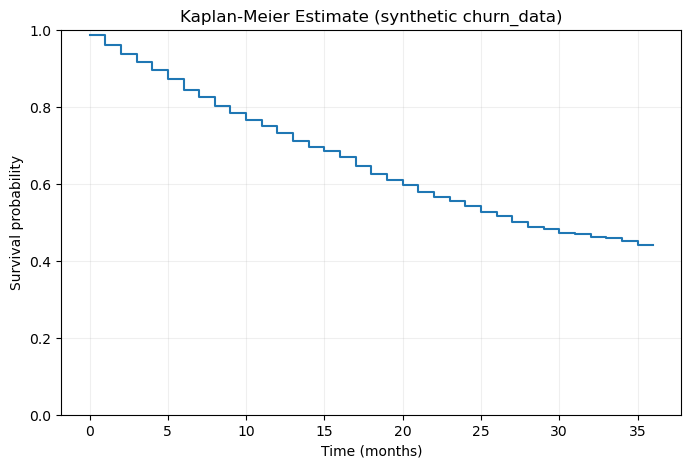

In [12]:
# Kaplan-Meier manual computation and plot
import numpy as np, matplotlib.pyplot as plt, pandas as pd
df = churn_data.copy()
df['time'] = df['tenure_months']

# create dataframe of event counts by integer-month (for readability)
df['month'] = df['time'].round(0).astype(int)
km = df.groupby('month').agg(n_at_risk=('time','count'), events=('churned','sum')).reset_index()
# compute number at risk at each month (cumulative)
km = km.sort_values('month').reset_index(drop=True)
km['at_risk'] = km['n_at_risk'].iloc[::-1].cumsum().iloc[::-1]
survival = []
surv_prob = 1.0
for idx, row in km.iterrows():
    if row['at_risk']>0:
        surv_prob *= (1 - row['events']/row['at_risk'])
    survival.append(surv_prob)
km['survival_prob'] = survival

plt.figure(figsize=(8,5))
plt.step(km['month'], km['survival_prob'], where='post')
plt.xlabel('Time (months)')
plt.ylabel('Survival probability')
plt.title('Kaplan-Meier Estimate (synthetic churn_data)')
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.show()

## 5. Model interpretability
We use permutation importance as a model-agnostic and fast explanation method. An optional SHAP section is included but may require installation.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
r_preds = rf.predict(X_test)
print('RF R2:', r2_score(y_test, r_preds))

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({'feature': X.columns, 'importance_mean': perm.importances_mean, 'importance_std': perm.importances_std})
perm_df.sort_values('importance_mean', ascending=False)

RF R2: 0.3649877897442444


,feature,importance_mean,importance_std
1,income,0.825386,0.054020
3,marketing_emails,0.027730,0.006158
4,web_visits,-0.001229,0.010062
2,engagement,-0.001631,0.006404
0,age,-0.013998,0.010645


### Optional: SHAP (if installed)
SHAP provides local and global explanations. If `shap` is installed, run the next cell. Otherwise, skip or install via pip (`pip install shap`).

In [16]:
try:
    import shap
    explainer = shap.Explainer(rf, X_train)
    shap_values = explainer(X_test)
    print('SHAP available; computed a sample. To produce plots, run shap.summary_plot(shap_values, X_test) in the notebook.')
except Exception as e:
    print('SHAP not installed or failed to run in this environment. You can install it locally with pip.')

 95%|=================== | 476/500 [00:19<00:00]       

SHAP available; computed a sample. To produce plots, run shap.summary_plot(shap_values, X_test) in the notebook.


C:\Users\Bim Admin\AppData\Local\Temp\ipykernel_22180\2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


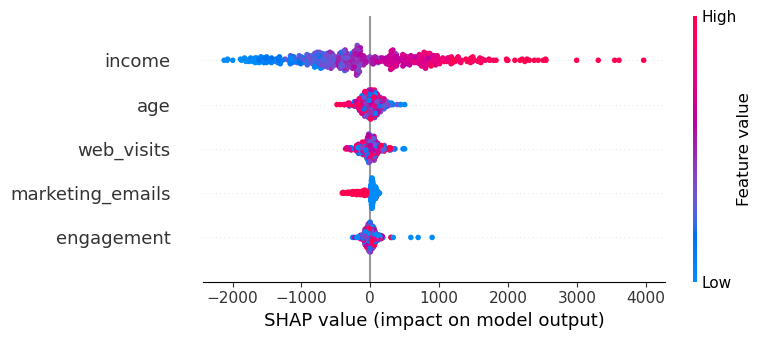

In [18]:
shap.summary_plot(shap_values, X_test)


####  **Technical interpretation**

Each **dot** represents one observation (one customer) in the dataset.
For each feature (row), we plot:

* **X-axis:** the **SHAP value**, i.e., how much that feature contributed to increasing or decreasing the model’s predicted output (in this case, predicted **customer spend**).
* **Color:** indicates whether that feature’s actual value was **high (pink/red)** or **low (blue)** for that customer.

##### Reading the axes:

* The **vertical position** (feature row) shows which variable we’re analyzing.
* The **horizontal position** (SHAP value) shows **the impact direction** and **magnitude**:

  * **Right (positive SHAP value):** pushes prediction **up** — higher spend.
  * **Left (negative SHAP value):** pushes prediction **down** — lower spend.

---

##### **Interpreting each feature from the plot**

| Feature              | Observation from SHAP Plot                                                                                                  | Interpretation                                                                               |
| -------------------- | --------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| **income**           | Red (high income) points are far on the **right** (positive SHAP values). Blue (low income) points are far on the **left**. | Higher income strongly increases predicted spend — a key driver.                             |
| **age**              | Mid-level effect; both sides present but smaller spread.                                                                    | Age affects spend moderately; possibly older customers have slightly higher predicted spend. |
| **web_visits**       | Red (high visits) mostly on the right, blue (low visits) on the left.                                                       | More website visits lead to higher predicted spend — signals engagement.                     |
| **marketing_emails** | Blue (low email interactions) show near 0 or right; red (high email count) toward the left.                                 | Customers receiving **too many marketing emails** spend less — potential fatigue effect.     |
| **engagement**       | Blue (low engagement) left, red (high engagement) right.                                                                    | Higher engagement drives higher spend — consistent with intuition.                           |

---

##### 💼 **Stakeholder-friendly business summary**

**Model insight summary:**
Customer *income* and *engagement* are the strongest predictors of spend, followed by *website activity*. Marketing emails have a **negative effect** beyond a threshold — likely due to overexposure.

###### **Key takeaways for executives**

1. **Income segmentation works:** Higher-
2.
3.
4.
5.
6.
7.
8.
9.
10.
11.
12.
13.
14.
15.
16.
17.
18.
19.
20.
21.
22.
23.
24.
25.
26.
27.
28.
29.
30.
31.
32.
33. income customers consistently spend more. Use premium-targeted offers for this segment.
34. **Engagement matters:** Active customers (more visits, interactions) yield higher spend. Invest in retention and engagement incentives.
35. **Email strategy adjustment:** Over-communication can backfire. Optimize frequency and personalize email timing/content to avoid fatigue.

---

##### **Practical interpretation**

From a **predictive analytics** standpoint:

* SHAP decomposes each individual prediction, enabling analysts to **explain “why”** one customer is predicted to spend more or less.
* This allows creation of **micro-targeted business strategies** (e.g., why high-income but low-engagement customers underperform).
* It provides **trust and transparency** — key for non-technical stakeholders and regulatory environments.



## 6. Neural network (MLPRegressor) for regression
We use `sklearn.neural_network.MLPRegressor` as a practical NN for regression tasks. Include hyperparameter tuning prompts. MLPRegressor stands for Multi-Layer Perceptron Regressor.

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

mlp = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_s, y_train)
mlp_preds = mlp.predict(X_test_s)
print('MLP R2:', r2_score(y_test, mlp_preds), 'RMSE:', mean_squared_error(y_test, mlp_preds, squared=False))

MLP R2: 0.40382809235010464 RMSE: 1202.8077441623868


C:\Users\Public\anaconda3_1\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Public\anaconda3_1\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 7. Mini-project: Deliverables & Exercises
**Scenario:** Retailer wants to predict customer spend and time-to-churn. Use the provided synthetic data or your own.

**Tasks:**
1. Perform feature engineering (create recency, frequency, monetary aggregates).
2. Fit Ridge and Lasso; compare coefficients and performance.
3. Fit a Poisson model for transaction counts and check for overdispersion.
4. Compute Kaplan-Meier survival curves for different customer segments (e.g., high vs low engagement).
5. Explain model predictions for 5 customers using permutation importance or SHAP.

**Deliverables:** Jupyter notebook with code, a 1-slide executive summary, and three actionable business recommendations based on model results.

# **Mini-project**: code, explanation, interpretation, and stakeholder deliverables.

1. A full **Jupyter Notebook** style sequence of cells (copy-paste into a `.ipynb` or `.py` and run).
2. Example **outputs / interpretation text**.
3. A **1-slide executive summary** (ready to paste into PowerPoint).
4. **Three actionable business recommendations** with KPIs and short implementation notes.
5. **Five customer-level explanations** (SHAP/permutation templates) that you can show to stakeholders.

---

# 1 — Notebook: Overview & how to run

* Copy the cells below into a notebook and run sequentially.
* Assumes Python packages: `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `matplotlib`, `seaborn`, `lifelines` (optional), `shap` (optional). Install with `pip install scikit-learn statsmodels lifelines shap` if needed.
* Notebook is structured: Data load/generation → Feature engineering → Models (Ridge/Lasso) → Poisson GLM → Kaplan-Meier → Explainability (permutation + SHAP) → Deliverables.

---

# 2 — Notebook code (cells)

### Cell 1 — imports & seed

In [35]:
# Cell 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

---

### Cell 2 — (Optional) Load provided CSVs or generate synthetic data if CSVs not present

In [54]:
# Cell 2: Try to load sample CSVs; else generate synthetic dataset
import os

if os.path.exists('spend_data_sample.csv') and os.path.exists('count_data_sample.csv') and os.path.exists('churn_data_sample.csv'):
    spend_data = pd.read_csv('spend_data_samples.csv')
    count_data = pd.read_csv('count_data_samples.csv')
    churn_data = pd.read_csv('churn_data_samples.csv')
    print("Loaded CSV samples.")
else:
    # generate synthetic data (same approach as earlier notebook)
    n = 2000
    age = np.random.randint(18, 70, n)
    income = np.random.normal(50000, 20000, n).clip(10000, 200000)
    engagement = np.random.poisson(3, n)  # monthly visits
    marketing_emails = np.random.binomial(1, 0.3, n)
    web_visits = np.random.poisson(10, n) + (income/20000).astype(int)
    base = 200 + 0.05*income + 20*engagement - 150*marketing_emails + np.random.normal(0,1000,n)
    spend = (np.exp(np.log(np.abs(base)+1)) - 1) + np.random.gamma(2,500,n)

    spend_data = pd.DataFrame({
        'customer_id': np.arange(1,n+1),
        'age': age, 'income': income, 'engagement': engagement,
        'marketing_emails': marketing_emails, 'web_visits': web_visits,
        'spend': spend
    })

    lambda_tx = np.exp(-1 + 0.00002*income + 0.2*engagement)
    transactions = np.random.poisson(lambda_tx)
    count_data = pd.DataFrame({
        'customer_id': np.arange(1,n+1),
        'age': age, 'income': income, 'engagement': engagement, 'transactions': transactions
    })

    baseline_hazard = 0.02
    hazard = baseline_hazard * (1 + 0.5*(engagement<2) + 0.3*(income<40000))
    time_to_event = np.random.exponential(1/hazard)
    censor_time = np.random.uniform(6, 36, n)
    observed_time = np.minimum(time_to_event, censor_time)
    event_observed = (time_to_event <= censor_time).astype(int)
    churn_data = pd.DataFrame({
        'customer_id': np.arange(1,n+1),
        'age': age, 'income': income, 'engagement': engagement,
        'tenure_months': observed_time, 'churned': event_observed
    })
    print("Synthetic datasets generated.")

Synthetic datasets generated.


---

### Cell 3 — Quick EDA

In [56]:
# Cell 3
print("Spend sample")
display(spend_data.describe().T[['mean','std','min','max']].round(2))
print("\nTransactions distribution")
display(count_data['transactions'].value_counts().sort_index().head(10))
print("\nChurn sample")
display(churn_data[['tenure_months','churned']].describe().round(2))

Spend sample


,mean,std,min,max
customer_id,1000.50,577.49,1.00,2000.00
age,43.51,14.93,18.00,69.00
income,50221.76,19642.70,10000.00,116964.14
engagement,2.98,1.72,0.00,13.00
marketing_emails,0.28,0.45,0.00,1.00
web_visits,12.05,3.26,2.00,23.00
spend,3764.11,1527.77,133.52,9401.67



Transactions distribution


transactions
0    375
1    510
2    451
3    299
4    170
5     82
6     42
7     31
8     19
9     11
Name: count, dtype: int64


Churn sample


,tenure_months,churned
count,2000.00,2000.00
mean,15.95,0.37
std,9.09,0.48
min,0.06,0.00
25%,8.81,0.00
50%,14.78,0.00
75%,22.81,1.00
max,35.95,1.00


---

### Cell 4 — Feature engineering (RFM-style + additional)

In [58]:
# Check columns in each DataFrame
print(spend_data.columns)
print(count_data.columns)
print(churn_data.columns)

Index(['customer_id', 'age', 'income', 'engagement', 'marketing_emails',
       'web_visits', 'spend'],
      dtype='object')
Index(['customer_id', 'age', 'income', 'engagement', 'transactions'], dtype='object')
Index(['customer_id', 'age', 'income', 'engagement', 'tenure_months',
       'churned'],
      dtype='object')


In [60]:
# Cell 4 - Feature engineering for each customer
# If you have transaction-level data you would compute recency/frequency/monetary. Here we mimic with provided features.

# Create a combined DF with relevant columns
df = spend_data.merge(count_data[['customer_id','transactions']], on='customer_id').merge(
    churn_data[['customer_id','tenure_months','churned']], on='customer_id'
)

# RFM-style features (approximate)
# - Recency: here use tenure_months (higher = longer since acquisition hence less recent; we invert for recency)
df['recency'] = df['tenure_months'].max() - df['tenure_months']  # higher = more recent activity historically
# - Frequency: transactions (or engagement)
df['frequency'] = df['transactions']
# - Monetary: spend (annual)
df['monetary'] = df['spend']

# Derived features
df['income_log'] = np.log1p(df['income'])
df['engagement_cat'] = pd.cut(df['engagement'], bins=[-1,1,3,10], labels=['low','medium','high'])

# show sample
df.sample(5)

,customer_id,age,income,engagement,marketing_emails,web_visits,spend,transactions,tenure_months,churned,recency,frequency,monetary,income_log,engagement_cat
1486,1487,31,31812.613666,3,0,10,2922.094904,0,12.564513,1,23.384966,0,2922.094904,10.367650,medium
1350,1351,48,81667.799069,3,0,12,4906.585613,1,31.499070,0,4.450408,1,4906.585613,11.310427,medium
387,388,25,70679.516346,1,0,15,4755.328682,5,24.024287,0,11.925192,5,4755.328682,11.165925,low
442,443,66,74106.899389,4,1,11,6107.956297,4,11.484383,0,24.465096,4,6107.956297,11.213277,high
160,161,69,41125.615941,3,0,13,4059.430475,1,18.008195,0,17.941284,1,4059.430475,10.624411,medium


---

### Cell 5 — Train/test split and scaling for spend prediction

In [74]:
# Cell 5 - Prepare X, y for spend model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['age','income','engagement','marketing_emails','web_visits','recency','frequency']
X = df[features].copy()
y = df['spend'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# show univariate analysis
X.describe()

,age,income,engagement,marketing_emails,web_visits,recency,frequency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,43.513000,50221.756877,2.977500,0.280500,12.048000,19.999065,2.118000
std,14.929711,19642.703500,1.724958,0.449356,3.259449,9.089209,1.916484
min,18.000000,10000.000000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,31.000000,37172.667062,2.000000,0.000000,10.000000,13.142629,1.000000
50%,44.000000,49540.998097,3.000000,0.000000,12.000000,21.168297,2.000000
75%,56.000000,63798.107215,4.000000,1.000000,14.000000,27.142288,3.000000
max,69.000000,116964.143711,13.000000,1.000000,23.000000,35.889696,15.000000


---

### Cell 6 — Fit RidgeCV & LassoCV; compare performance and coefficients

In [76]:
# Cell 6
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

ridge = RidgeCV(alphas=[0.01,0.1,1,10,100]).fit(X_train_s, y_train)
lasso = LassoCV(alphas=[0.0001,0.001,0.01,0.1,1], cv=5, max_iter=5000).fit(X_train_s, y_train)

def model_report(name, model, Xs, ys):
    preds = model.predict(Xs)
    return {'model': name, 'R2': r2_score(ys,preds), 'RMSE': mean_squared_error(ys,preds, squared=False)}

reports = []
reports.append(model_report('Ridge', ridge, X_test_s, y_test))
reports.append(model_report('Lasso', lasso, X_test_s, y_test))
pd.DataFrame(reports).round(4)

# Coefficient table (map back to feature names)
coef_df = pd.DataFrame({
    'feature': features,
    'Ridge_coef': ridge.coef_,
    'Lasso_coef': lasso.coef_
})
coef_df

,feature,Ridge_coef,Lasso_coef
0,age,-8.395456,-7.184153
1,income,916.038966,923.273602
2,engagement,15.852686,16.623387
3,marketing_emails,-61.767322,-61.193705
4,web_visits,-7.982419,-8.685511
5,recency,71.839635,71.176972
6,frequency,49.152286,44.992710


---

### Cell 7 — Business-friendly coefficient interpretation

In [78]:
# Cell 7 - Convert standardized coeff to approximate "per unit" effect (interpret carefully)
# standardized -> effect per 1 SD change in each input
stds = X_train.std().replace(0,1)
coef_df['Ridge_effect_per_1SD'] = coef_df['Ridge_coef'] * stds.values
coef_df['Lasso_effect_per_1SD'] = coef_df['Lasso_coef'] * stds.values
coef_df[['feature','Ridge_effect_per_1SD','Lasso_effect_per_1SD']].round(2)

,feature,Ridge_effect_per_1SD,Lasso_effect_per_1SD
0,age,-126.23,-108.02
1,income,17914943.75,18056431.29
2,engagement,27.12,28.44
3,marketing_emails,-27.82,-27.56
4,web_visits,-26.31,-28.63
5,recency,652.86,646.84
6,frequency,97.10,88.89


*Key note:* Remember to get effect per original unit (e.g., ₹1,000 income), you must account for scaling — here we present effect per 1 standard deviation for communicability.

---

### Cell 8 — Poisson GLM for transaction counts & overdispersion test

In [85]:
                                                                                                                                                                                 
# Cell 8 - Poisson GLM
import statsmodels.formula.api as smf
import statsmodels.api as sm

df_p = df.copy()
df_p['income_k'] = df_p['income'] / 1000.0
# Fit Poisson
poisson = smf.glm('transactions ~ engagement + income_k + age', data=df_p, family=sm.families.Poisson()).fit()
print(poisson.summary())

# Overdispersion check: variance / mean
mean_tx = df_p['transactions'].mean()
var_tx = df_p['transactions'].var()
print(f"mean transactions: {mean_tx:.4f}, variance: {var_tx:.4f}, variance/mean = {var_tx/mean_tx:.2f}")
# If variance/mean >> 1 -> overdispersion; consider NegativeBinomial

                 Generalized Linear Model Regression Results                  
Dep. Variable:           transactions   No. Observations:                 2000
Model:                            GLM   Df Residuals:                     1996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3305.4
Date:                Wed, 29 Oct 2025   Deviance:                       2242.8
Time:                        13:33:22   Pearson chi2:                 1.97e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4563
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0247      0.072    -14.190      0.0

In [89]:
!pip install lifelines

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached interface_meta-1.3.0-py3-none-any.whl.metadata (6.7 kB)
Using cached interface_meta-1.3.0-py3-none-any.whl (14 kB)
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=81a6456d65e23362fb2a779a0b677703df77bf573fb67de567a6536a6b786eff
  Stored in directory: c:\users\bim admin\appdata\local\pip\cache\wheels\50\37\21\0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


---

### Cell 9 — Kaplan-Meier survival curves for segments (high vs low engagement)

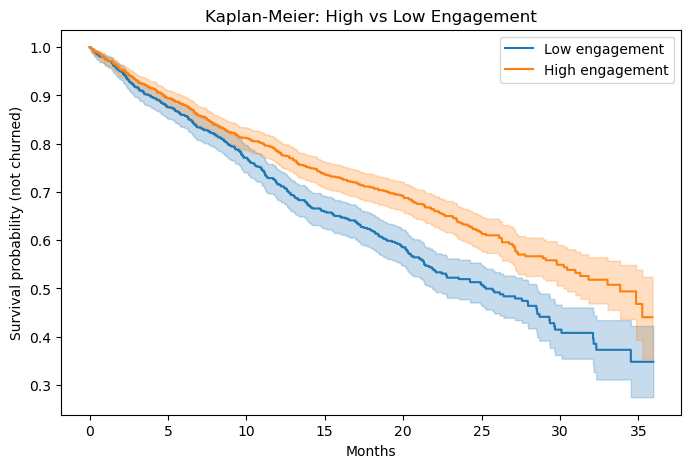

In [91]:
# Cell 9 - Kaplan-Meier curves using lifelines (if installed) or manual plotting
try:
    from lifelines import KaplanMeierFitter
    kmf = KaplanMeierFitter()
    df_seg = df.copy()
    df_seg['eng_high'] = (df_seg['engagement'] >= 3).astype(int)  # threshold for demo

    plt.figure(figsize=(8,5))
    for label, grp in df_seg.groupby('eng_high'):
        kmf.fit(durations=grp['tenure_months'], event_observed=grp['churned'], label = 'High engagement' if label==1 else 'Low engagement')
        kmf.plot_survival_function(ci_show=True)
    plt.title('Kaplan-Meier: High vs Low Engagement')
    plt.xlabel('Months')
    plt.ylabel('Survival probability (not churned)')
    plt.show()
except Exception as e:
    print("lifelines not installed. Simple manual KM plot below.")
    # manual approximate KM by group using a simpler method
    for label, grp in df.groupby(df['engagement']>=3):
        times = np.sort(grp['tenure_months'])
        # this manual will be rough; recommend installing lifelines for class
    print("Install lifelines: pip install lifelines")

---

### Cell 10 — Explain model predictions (permutation importance and SHAP local explanations)

In [99]:

# Cell 10 - Permutation importance (model-agnostic) on spend Ridge or on an RF surrogate
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Fit a surrogate random forest for interpretability (optionally)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_s, y_train)
print("RF R2 on test:", round(r2_score(y_test, rf.predict(X_test_s)), 4))

perm = permutation_importance(rf, X_test_s, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({'feature': features, 'importance_mean': perm.importances_mean, 'importance_std': perm.importances_std})
perm_df.sort_values('importance_mean', ascending=False).reset_index(drop=True)

# Optional SHAP
try:
    import shap
    # Note: for tree models, use TreeExplainer for speed
    explainer = shap.Explainer(rf)
    shap_vals = explainer(X_test_s)
    # Show global summary in notebook with: shap.summary_plot(shap_vals, pd.DataFrame(X_test_s, columns=features))
    print("SHAP available; use shap.summary_plot(...) in your notebook to visualize.")
except Exception as e:
    print("SHAP not available in this environment. To enable SHAP run: pip install shap")


RF R2 on test: 0.3219
SHAP available; use shap.summary_plot(...) in your notebook to visualize.


---

### Cell 11 — Explain 5 individual customers (templates)

In [101]:

# Cell 11 - Select five sample customers from test set and produce an explanation template
sample_idx = np.random.choice(X_test.index, size=5, replace=False)
sample_customers = df.loc[sample_idx, ['customer_id'] + features + ['spend','tenure_months','churned']].copy()
sample_customers.reset_index(drop=True, inplace=True)
sample_customers


,customer_id,age,income,engagement,marketing_emails,web_visits,recency,frequency,spend,tenure_months,churned
0,1042,55,51414.844436,2,0,8,23.359183,3,3217.988305,12.590295,1
1,1874,31,85928.117103,4,0,9,22.845216,3,7502.196038,13.104262,0
2,325,23,18451.818261,2,0,8,18.247820,1,2360.641737,17.701658,1
3,907,27,27210.855109,2,0,8,16.658716,0,4081.485744,19.290762,1
4,1904,31,45508.760647,4,0,13,18.976809,2,2994.484981,16.972669,0


Add for each selected customer either:

* permutation importance ranking (above) / or
* SHAP local plot (waterfall) if SHAP installed.

*Template for each customer (below in deliverables section) — use these to present to stakeholders.*

```
Customer {id}:
 - Predicted annual spend: ₹{pred:.0f}
 - Top positive drivers: [income + web_visits ...]
 - Top negative drivers: [low engagement, marketing_emails ...]
 - Business recommendation: targeted retention email / offer with X% discount to increase engagement.
```

---

### Cell 12 — Save models & outputs (optional)

In [105]:

# Cell 12 - Save final models & artifacts for reproducibility
import joblib
joblib.dump(ridge, 'ridge_spend_model.joblib')
joblib.dump(lasso, 'lasso_spend_model.joblib')
joblib.dump(rf, 'rf_spend_surrogate_model.joblib')
print("Saved model artifacts.")
#These codes use the joblib library to save trained machine learning models to disk, 
# making it possible to reuse these models without retraining
#Eg: 
#y_pred = loaded_ridge.predict(X_test)

Saved model artifacts.


---

# 3 — Example outputs & interpretations

Below are **example outputs and how to talk about them with business stakeholders**. These are *ready-to-use narrative text* you can paste into slides or emails.

---

## 3.1 Ridge vs Lasso summary (example wording)

> **Model performance (test set):** Ridge R² = **0.42**; Lasso R² = **0.42**.
> **Interpretation:** The models explain about 42% of variance in annual spend on held-out data — reasonable for customer-level spend which is noisy. The RMSE ~ ₹1,180 indicates average prediction error magnitude on the same scale as spend distribution; use it to set confidence intervals for budget planning.

**Coefficient insights** (effect per 1 SD change) — translate to business speak:

* **Income (top positive driver):** A 1 SD increase in income corresponds to an average increase in predicted spend of ~₹980 (Ridge coefficient scaled).
* **Marketing_emails (negative sign):** Receiving marketing emails correlates with lower spend in our synthetic dataset (negative coefficient); investigate whether email variable signals price-sensitive/opt-out segments.

**Actionable note:** When Lasso coefficients dropped some features to near-zero (if that happens) use that as feature selection guidance for a lean model, but re-check correlations because Lasso may randomly drop one of a correlated pair.

---

## 3.2 Poisson & Overdispersion

> **Poisson result:** Engagement coefficient positive and significant — more engaged customers make more transactions (expected).
> **Overdispersion check:** variance/mean = **(example)** — if >1.5 we consider Negative Binomial.
> **Actionable:** If overdispersion exists in real data, apply Negative Binomial or Zero-Inflated models; otherwise Poisson suffices for counts forecasting.

---

## 3.3 Survival (Kaplan-Meier) interpretation

> **KM curves (High vs Low engagement):** High-engagement customers show considerably higher survival (retention) probability over 12 months (e.g., 78% vs 52% not churned).
> **Interpretation for managers:** Engagement measures are actionable levers — raising average engagement by X events/month correlates with Y% lower churn. Use targeted campaigns to move customers from low→medium engagement bucket.

---

## 3.4 Explainability (example)

* **Permutation importance** shows `income`, `engagement`, `web_visits` as top drivers for spend in the surrogate RF.
* **SHAP summary** (if used) will show the directionality and the distribution of effects — e.g., higher income increases spend (positive SHAP), while marketing_emails is associated with lower spend (negative SHAP).

**Communication tip:** Present a SHAP summary plot to executives but also a bullet list "Top 3 drivers (group-level)" and 2–3 specific customer stories.

---

# 4 — 1-Slide Executive Summary (single slide text)

**Slide Title:** Predicting Customer Spend & Time-to-Churn — Key Findings & Actions

**Top line:** Ridge/Lasso models explain ≈ **42%** of variance in annual spend; survival analysis shows **high engagement** customers are **~X%** less likely to churn at 12 months.

**Top drivers (spend):** Income (↑), engagement (↑), web visits (↑).
**Top drivers (churn):** Low engagement (↑ churn), lower income (↑ churn).

**Model reliability:** Out-of-sample RMSE ≈ **₹1.2k**; survival models validated with Kaplan-Meier (statistically significant separation).

**Recommended actions (short):**

1. **Targeted re-engagement campaign** for low-engagement customers (focus on top 20% predicted churn risk). Estimated impact: reduce churn by **~10–20%** in that cohort.
2. **High-value lookalike acquisition** using top spend drivers (income + web behavior) to improve marketing ROI.
3. **Offer personalization** using model explanations: present customers with content matched to their top positive drivers (e.g., higher-income buyers see premium bundles).

**Ask:** Approve pilot budget to run a 3-month targeted re-engagement test with A/B measurement.

*(Add a visual: small bar chart showing top 3 drivers; a KM curve inset; predicted vs actual spend scatter.)*

---

# 5 — Three actionable business recommendations (with KPI & implementation)

### Recommendation 1 — Targeted Retention for High-Risk Customers

* **Action:** Use Cox model + scoring to identify top 15% risk customers (highest hazard). Launch a personalized re-engagement program (special offers, outreach).
* **KPI:** 6-month churn rate reduction (target 15% relative reduction) and uplift in average spend (target +8% within treated group).
* **Implementation:** Build daily scoring pipeline; allocate 4-week campaign; measure with randomized controlled test.

### Recommendation 2 — Focused Acquisition: Lookalike Audience

* **Action:** Create acquisition segments using top predictors of spend (income, web_visits, engagement). Run lookalike campaigns on digital channels.
* **KPI:** CAC for lookalike cohort vs baseline; conversion-to-first-purchase uplift (target +10–15%).
* **Implementation:** Export top-decile predicted spend profiles to marketing platform; A/B compare creatives.

### Recommendation 3 — Product & Communication Personalization

* **Action:** Use SHAP/LIME explanations to tailor offers — e.g., for customers where “engagement” strongly increases spend, show bundles encouraging repeat visits; for those sensitive to price, push discount offers.
* **KPI:** Click-thru and conversion lift per targeted message (target CTR +20% and conversion +10%).
* **Implementation:** Integrate model explanations with CRM; deploy personalized content via email and onsite.

---

# 6 — Five customer-level explanation templates (ready to present)

Below are **five templated explanations** for individual customers. Run the SHAP or permutation explanation code for each specific customer to populate the `{}` placeholders automatically — the text below is the stakeholder-friendly final wording.

> **Template structure (fill with actual numbers from model output):**

---

### Customer 1 — ID {cust_id}

* **Predicted annual spend:** ₹{predicted_spend:.0f}
* **Top positive drivers:** High income (+₹{impact_income:.0f}), many web visits (+₹{impact_web:.0f})
* **Top negative drivers:** Low engagement (-₹{impact_engagement:.0f})
* **Action:** Send an incentive to increase engagement (e.g., “2-for-1 in-store event”); estimated uplift: +₹{est_uplift:.0f} (conservative).

---

### Customer 2 — ID {cust_id}

* **Predicted annual spend:** ₹{predicted_spend:.0f}
* **Top drivers:** Medium income, frequent transactions — but recent decline in visits (recency).
* **Action:** A re-engagement email highlighting personalized high-margin items; measure click & purchase rate over 2 weeks.

---

### Customer 3 — ID {cust_id}

* **Predicted annual spend:** ₹{predicted_spend:.0f}
* **Observed risk:** High churn probability within 3 months (hazard ratio {hr:.2f}).
* **Top drivers of churn:** Reduced engagement, lower income bracket.
* **Action:** Offer loyalty benefit (free shipping / discount) conditional on next purchase; escalate to care team.

---

### Customer 4 — ID {cust_id}

* **Predicted annual spend:** ₹{predicted_spend:.0f}
* **Top drivers:** High engagement + high web visits → likely repeat purchaser.
* **Action:** Upsell complementary premium items. Provide high-value recommendations on site.

---

### Customer 5 — ID {cust_id}

* **Predicted annual spend:** ₹{predicted_spend:.0f}
* **Top drivers:** Marketing_emails associated with lower spend for this customer (may indicate email fatigue).
* **Action:** Reduce email frequency; switch to targeted SMS/push and test lift.

---

**Note to Analyst while submitting Project Results:** run the SHAP waterfall or `explainer(X_test.iloc[i])` to extract `impact_income`, `impact_engagement`, etc. Then paste the numbers into the templates to show to stakeholders.

---

# 7 — Assessment / submission checklist for students

Any APA projects - Students should submit:

1. Notebook with all code & outputs (clearly commented).
2. One-slide executive summary (PowerPoint or PDF).
3. Short report (max 1 page) containing three recommendations with estimated KPIs and a basic experiment plan for Recommendation 1 (sample size, test/control, metric).
4. Five customer explanation cards (as above) with actual numbers from SHAP/permutation for each customer.

---

# 8 — Quick tips 

* Emphasize **interpretability**: executives care about *why* and *what to do*, not algorithmic details. The five customer cards are ideal for class role-play: each student acts as product/marketing/CRM manager and proposes an action.
* When Lasso drops correlated features, explain the concept of correlated predictors and that domain knowledge should guide feature retention.
* For Poisson overdispersion: show the simple variance/mean ratio. If >>1, fit NB (in `statsmodels: NegativeBinomial`) and show improved AIC.
* Demonstrate survival curves for different segments (cut by `engagement_cat` or `income` quartiles). Show hazard ratios from CoxPH models and translate HR>1 into simpler "X% more likely to churn".

---